In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

# Charger le dataset — remplace le nom du fichier si besoin
df = pd.read_csv(r'C:\Users\yanis\Downloads\archive\data.csv')

# Premier aperçu
print(df.shape)
print(df.head())
print(df.info())

(1143, 15)
    ad_id reporting_start reporting_end campaign_id fb_campaign_id    age  \
0  708746      17/08/2017    17/08/2017         916         103916  30-34   
1  708749      17/08/2017    17/08/2017         916         103917  30-34   
2  708771      17/08/2017    17/08/2017         916         103920  30-34   
3  708815      30/08/2017    30/08/2017         916         103928  30-34   
4  708818      17/08/2017    17/08/2017         916         103928  30-34   

  gender  interest1  interest2  interest3  impressions  clicks  spent  \
0      M         15         17         17       7350.0       1   1.43   
1      M         16         19         21      17861.0       2   1.82   
2      M         20         25         22        693.0       0   0.00   
3      M         28         32         32       4259.0       1   1.25   
4      M         28         33         32       4133.0       1   1.29   

   total_conversion  approved_conversion  
0               2.0                  1.0  
1

In [5]:
# Nettoyage des valeurs manquantes
df['total_conversion'] = df['total_conversion'].fillna(0)
df['approved_conversion'] = df['approved_conversion'].fillna(0)

# Calcul des métriques clés
df['CTR'] = (df['clicks'] / df['impressions'] * 100).round(2)          # Taux de clic %
df['CPC'] = (df['spent'] / df['clicks'].replace(0, np.nan)).round(2)   # Coût par clic
df['CPA'] = (df['spent'] / df['approved_conversion'].replace(0, np.nan)).round(2)  # Coût par acquisition
df['conv_rate'] = (df['approved_conversion'] / df['clicks'].replace(0, np.nan) * 100).round(2)  # Taux de conversion %

# Résumé global
print("=== RÉSUMÉ GLOBAL ===")
print(f"Budget total dépensé : {df['spent'].sum():.0f} €")
print(f"Impressions totales : {df['impressions'].sum():,.0f}")
print(f"Clics totaux : {df['clicks'].sum():,}")
print(f"CTR moyen : {df['CTR'].mean():.2f} %")
print(f"Conversions totales : {df['approved_conversion'].sum():.0f}")
print(f"CPA moyen : {df['CPA'].mean():.2f} €")

=== RÉSUMÉ GLOBAL ===
Budget total dépensé : 20114 €
Impressions totales : 78,552,673
Clics totaux : 13,293
CTR moyen : inf %
Conversions totales : 585
CPA moyen : 22.58 €


In [6]:
# Correction du CTR (éviter division par zéro)
df['CTR'] = np.where(df['impressions'] > 0, 
                      (df['clicks'] / df['impressions'] * 100).round(2), 
                      0)

# Résumé corrigé
print("=== RÉSUMÉ GLOBAL CORRIGÉ ===")
print(f"Budget total dépensé : {df['spent'].sum():.0f} €")
print(f"Impressions totales : {df['impressions'].sum():,.0f}")
print(f"Clics totaux : {df['clicks'].sum():,}")
print(f"CTR moyen : {df['CTR'].mean():.3f} %")
print(f"Conversions totales : {df['approved_conversion'].sum():.0f}")
print(f"CPA moyen : {df['CPA'].mean():.2f} €")

# Analyse par campagne
print("\n=== PERFORMANCE PAR CAMPAGNE ===")
campagne = df.groupby('campaign_id').agg(
    budget_depense=('spent', 'sum'),
    impressions=('impressions', 'sum'),
    clics=('clicks', 'sum'),
    conversions=('approved_conversion', 'sum'),
    CTR_moyen=('CTR', 'mean'),
    CPA_moyen=('CPA', 'mean')
).round(2)

campagne['taux_conversion'] = (campagne['conversions'] / campagne['clics'] * 100).round(2)
print(campagne)

=== RÉSUMÉ GLOBAL CORRIGÉ ===
Budget total dépensé : 20114 €
Impressions totales : 78,552,673
Clics totaux : 13,293
CTR moyen : 2.618 %
Conversions totales : 585
CPA moyen : 22.58 €

=== PERFORMANCE PAR CAMPAGNE ===
             budget_depense  impressions  clics  conversions  CTR_moyen  \
campaign_id                                                               
1178               16577.16  69902476.00   9577        378.0       0.01   
30-34                166.00      7559.18    541          0.0      12.61   
35-39                 78.00      5966.91    269          0.0       8.10   
40-44                 88.00      7252.10    288          0.0       6.25   
45-49                162.00     18306.80    521          0.0       5.12   
916                  149.71    482925.00    113         24.0       0.02   
936                 2893.37   8128187.00   1984        183.0       0.02   

             CPA_moyen  taux_conversion  
campaign_id                              
1178             44.27  

=== PERFORMANCE PAR CAMPAGNE ===
Empty DataFrame
Columns: [budget_depense, impressions, clics, conversions, CTR_moyen, CPA_moyen, taux_conversion, budget_%]
Index: []


AttributeError: 'Axes' object has no attribute 'set_'

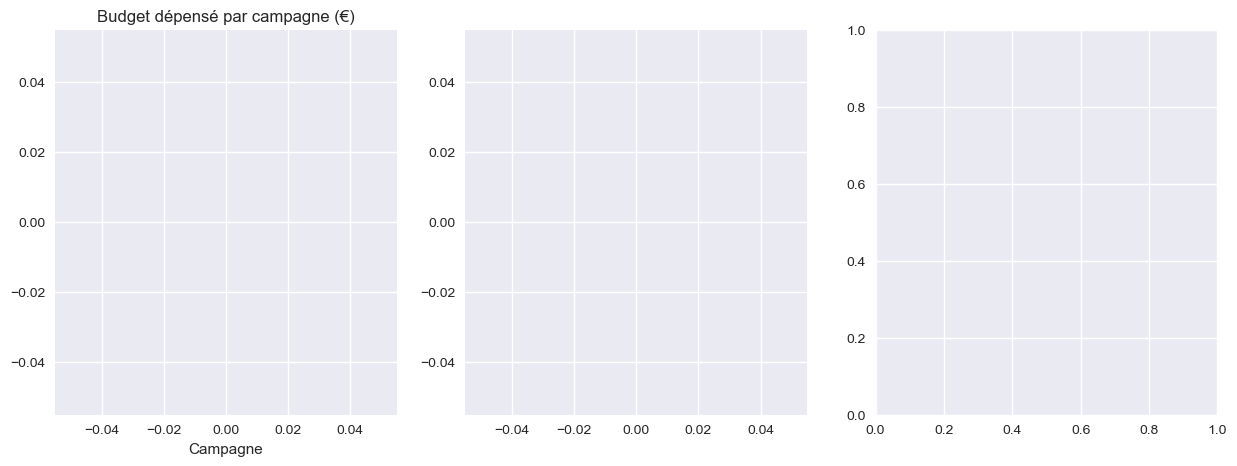

In [7]:
# Garder uniquement les vraies campagnes (IDs numériques)
campagnes_reelles = df[df['campaign_id'].isin([916, 936, 1178])]

# Analyse par campagne corrigée
print("=== PERFORMANCE PAR CAMPAGNE ===")
campagne = campagnes_reelles.groupby('campaign_id').agg(
    budget_depense=('spent', 'sum'),
    impressions=('impressions', 'sum'),
    clics=('clicks', 'sum'),
    conversions=('approved_conversion', 'sum'),
    CTR_moyen=('CTR', 'mean'),
    CPA_moyen=('CPA', 'mean')
).round(2)

campagne['taux_conversion'] = (campagne['conversions'] / campagne['clics'] * 100).round(2)
campagne['budget_%'] = (campagne['budget_depense'] / campagne['budget_depense'].sum() * 100).round(1)
print(campagne)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Budget par campagne
axes[0].bar(campagne.index.astype(str), campagne['budget_depense'], color=['#E8593C','#1D9E75','#7F77DD'])
axes[0].set_title('Budget dépensé par campagne (€)')
axes[0].set_xlabel('Campagne')

# Taux de conversion
axes[1].bar(campagne.index.astype(str), campagne['taux_conversion'], color=['#E8593C','#1D9E75','#7F77DD'])
axes[1].set_

In [8]:
# Vérifier les vraies valeurs de campaign_id
print(df['campaign_id'].unique())
print(df['campaign_id'].dtype)

['916' '936' '1178' '45-49' '30-34' '35-39' '40-44']
object


=== PERFORMANCE PAR CAMPAGNE ===
             budget_depense  impressions  clics  conversions  CTR_moyen  \
campaign_id                                                               
1178               16577.16   69902476.0   9577        378.0       0.01   
916                  149.71     482925.0    113         24.0       0.02   
936                 2893.37    8128187.0   1984        183.0       0.02   

             CPA_moyen  taux_conversion  budget_%  
campaign_id                                        
1178             44.27             3.95      84.5  
916               3.14            21.24       0.8  
936               5.50             9.22      14.7  


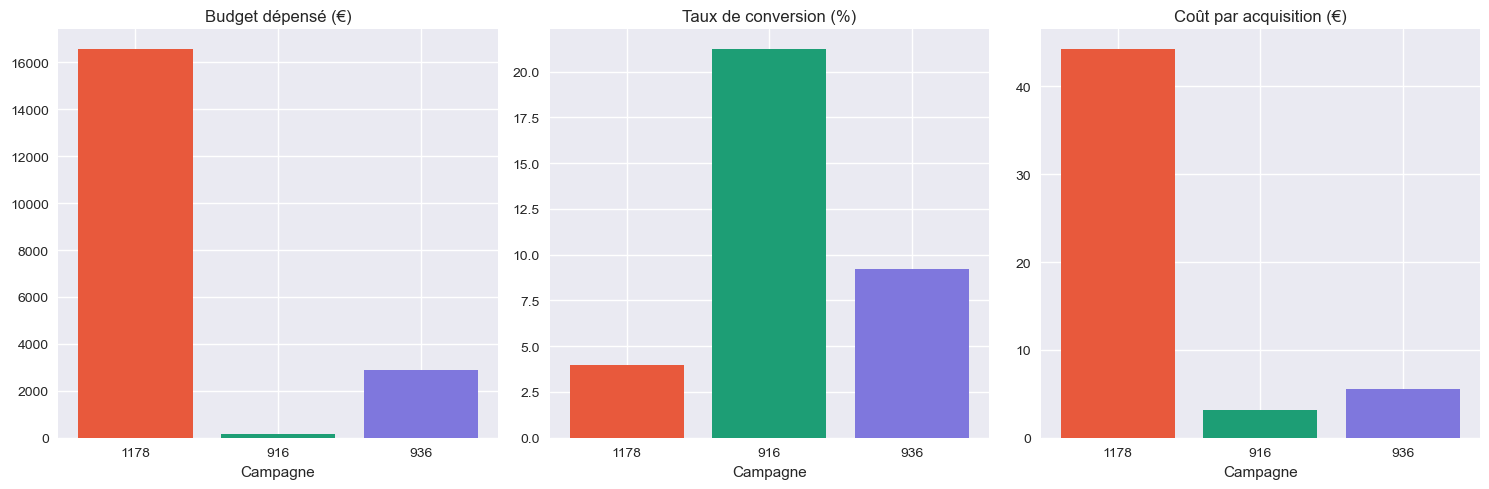

Graphique sauvegardé !


In [9]:
# Filtrer les vraies campagnes
campagnes_reelles = df[df['campaign_id'].isin(['916', '936', '1178'])]

# Analyse par campagne
print("=== PERFORMANCE PAR CAMPAGNE ===")
campagne = campagnes_reelles.groupby('campaign_id').agg(
    budget_depense=('spent', 'sum'),
    impressions=('impressions', 'sum'),
    clics=('clicks', 'sum'),
    conversions=('approved_conversion', 'sum'),
    CTR_moyen=('CTR', 'mean'),
    CPA_moyen=('CPA', 'mean')
).round(2)

campagne['taux_conversion'] = (campagne['conversions'] / campagne['clics'] * 100).round(2)
campagne['budget_%'] = (campagne['budget_depense'] / campagne['budget_depense'].sum() * 100).round(1)
print(campagne)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(campagne.index, campagne['budget_depense'], color=['#E8593C','#1D9E75','#7F77DD'])
axes[0].set_title('Budget dépensé (€)')
axes[0].set_xlabel('Campagne')

axes[1].bar(campagne.index, campagne['taux_conversion'], color=['#E8593C','#1D9E75','#7F77DD'])
axes[1].set_title('Taux de conversion (%)')
axes[1].set_xlabel('Campagne')

axes[2].bar(campagne.index, campagne['CPA_moyen'], color=['#E8593C','#1D9E75','#7F77DD'])
axes[2].set_title('Coût par acquisition (€)')
axes[2].set_xlabel('Campagne')

plt.tight_layout()
plt.savefig('analyse_campagnes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

In [10]:
# Interprétation analytique
print("=== ANALYSE & RECOMMANDATIONS ===")
print("""
CAMPAGNE 916 — La pépite cachée
- Budget : seulement 150 € (0.8% du budget total)
- Taux de conversion : 21.24% — le meilleur de loin
- CPA : 3.14 € — 14x moins cher que la campagne 1178
→ RECOMMANDATION : Augmenter massivement le budget sur cette campagne

CAMPAGNE 1178 — Le gouffre financier  
- Budget : 16 577 € (84.5% du budget total !)
- Taux de conversion : 3.95% — le plus faible
- CPA : 44.27 € — extrêmement élevé
→ RECOMMANDATION : Réduire le budget, revoir le ciblage et les visuels

CAMPAGNE 936 — La campagne équilibrée
- Budget : 2 893 € (14.7% du budget total)
- Taux de conversion : 9.22% — correct
- CPA : 5.50 € — très raisonnable
→ RECOMMANDATION : Maintenir et optimiser progressivement
""")

# Potentiel si budget réalloué
budget_total = 16577.16 + 149.71 + 2893.37
conversions_actuelles = 378 + 24 + 183
cpa_optimal = 3.14  # CPA de la campagne 916

conversions_potentielles = budget_total / cpa_optimal
print(f"=== IMPACT D'UNE RÉALLOCATION BUDGÉTAIRE ===")
print(f"Budget total : {budget_total:.0f} €")
print(f"Conversions actuelles : {conversions_actuelles:.0f}")
print(f"Conversions potentielles si tout sur campagne 916 : {conversions_potentielles:.0f}")
print(f"Gain potentiel : +{conversions_potentielles - conversions_actuelles:.0f} conversions (+{((conversions_potentielles/conversions_actuelles)-1)*100:.0f}%)")

=== ANALYSE & RECOMMANDATIONS ===

CAMPAGNE 916 — La pépite cachée
- Budget : seulement 150 € (0.8% du budget total)
- Taux de conversion : 21.24% — le meilleur de loin
- CPA : 3.14 € — 14x moins cher que la campagne 1178
→ RECOMMANDATION : Augmenter massivement le budget sur cette campagne

CAMPAGNE 1178 — Le gouffre financier  
- Budget : 16 577 € (84.5% du budget total !)
- Taux de conversion : 3.95% — le plus faible
- CPA : 44.27 € — extrêmement élevé
→ RECOMMANDATION : Réduire le budget, revoir le ciblage et les visuels

CAMPAGNE 936 — La campagne équilibrée
- Budget : 2 893 € (14.7% du budget total)
- Taux de conversion : 9.22% — correct
- CPA : 5.50 € — très raisonnable
→ RECOMMANDATION : Maintenir et optimiser progressivement

=== IMPACT D'UNE RÉALLOCATION BUDGÉTAIRE ===
Budget total : 19620 €
Conversions actuelles : 585
Conversions potentielles si tout sur campagne 916 : 6248
Gain potentiel : +5663 conversions (+968%)


=== PERFORMANCE PAR TRANCHE D'ÂGE ===
        budget  clics  conversions  impressions    CPA  taux_conversion    CTR
age                                                                           
30-34  7693.22   4433        328.0   35678593.0  23.45             7.40  0.012
35-39  5145.52   3005        129.0   20165377.0  39.89             4.29  0.015
40-44  4337.63   2660         82.0   15881589.0  52.90             3.08  0.017
45-49  2443.87   1576         46.0    6788029.0  53.13             2.92  0.023

=== PERFORMANCE PAR GENRE ===
          budget  clics  conversions    CPA  taux_conversion
gender                                                      
F        2450.21   1685        104.0  23.56             6.17
M       17170.03   9989        481.0  35.70             4.82


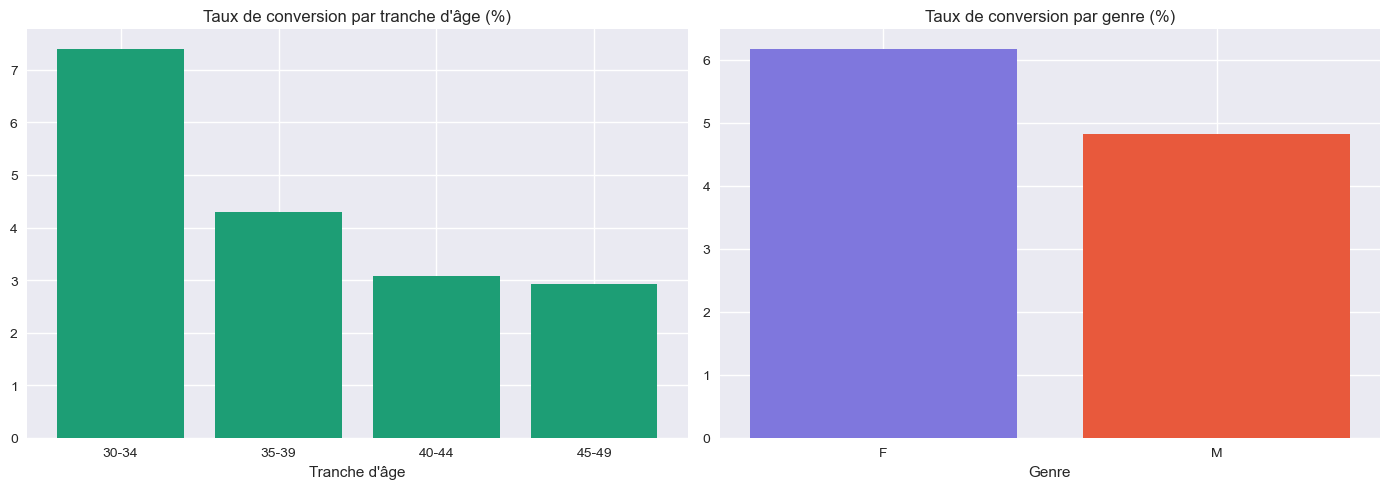

Graphique sauvegardé !


In [11]:
# Analyse par tranche d'âge
print("=== PERFORMANCE PAR TRANCHE D'ÂGE ===")
age = campagnes_reelles.groupby('age').agg(
    budget=('spent', 'sum'),
    clics=('clicks', 'sum'),
    conversions=('approved_conversion', 'sum'),
    impressions=('impressions', 'sum')
).round(2)

age['CPA'] = (age['budget'] / age['conversions'].replace(0, np.nan)).round(2)
age['taux_conversion'] = (age['conversions'] / age['clics'].replace(0, np.nan) * 100).round(2)
age['CTR'] = (age['clics'] / age['impressions'] * 100).round(3)
print(age.sort_values('taux_conversion', ascending=False))

# Analyse par genre
print("\n=== PERFORMANCE PAR GENRE ===")
genre = campagnes_reelles.groupby('gender').agg(
    budget=('spent', 'sum'),
    clics=('clicks', 'sum'),
    conversions=('approved_conversion', 'sum')
).round(2)

genre['CPA'] = (genre['budget'] / genre['conversions'].replace(0, np.nan)).round(2)
genre['taux_conversion'] = (genre['conversions'] / genre['clics'].replace(0, np.nan) * 100).round(2)
print(genre)

# Visualisation âge + genre
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de conversion par âge
age_sorted = age.sort_values('taux_conversion', ascending=False)
axes[0].bar(age_sorted.index, age_sorted['taux_conversion'], color='#1D9E75')
axes[0].set_title('Taux de conversion par tranche d\'âge (%)')
axes[0].set_xlabel('Tranche d\'âge')

# Taux de conversion par genre
axes[1].bar(genre.index, genre['taux_conversion'], color=['#7F77DD', '#E8593C'])
axes[1].set_title('Taux de conversion par genre (%)')
axes[1].set_xlabel('Genre')

plt.tight_layout()
plt.savefig('analyse_age_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé !")

=== INSIGHTS CIBLAGE ===

TRANCHE D'ÂGE — Résultat sans appel
- 30-34 ans : taux de conversion 7.40% — meilleur segment de loin
- 45-49 ans : taux de conversion 2.92% — 2.5x moins efficace
→ RECOMMANDATION : Concentrer 70% du budget sur les 30-34 ans
→ Tester un ciblage 30-34 exclusif sur la campagne 916

GENRE — Surprise importante
- Femmes : CPA 23.56 € — 34% moins cher que les hommes
- Hommes : reçoivent 87.5% du budget mais convertissent moins bien
→ RECOMMANDATION : Rééquilibrer vers les femmes 30-34 ans
→ C'est probablement le profil le plus rentable de tout le dataset

=== PROFIL IDÉAL : FEMMES 30-34 ANS ===
Budget dépensé : 302 €
Conversions : 43
CPA : 7.02 €
Taux de conversion : 19.37 %


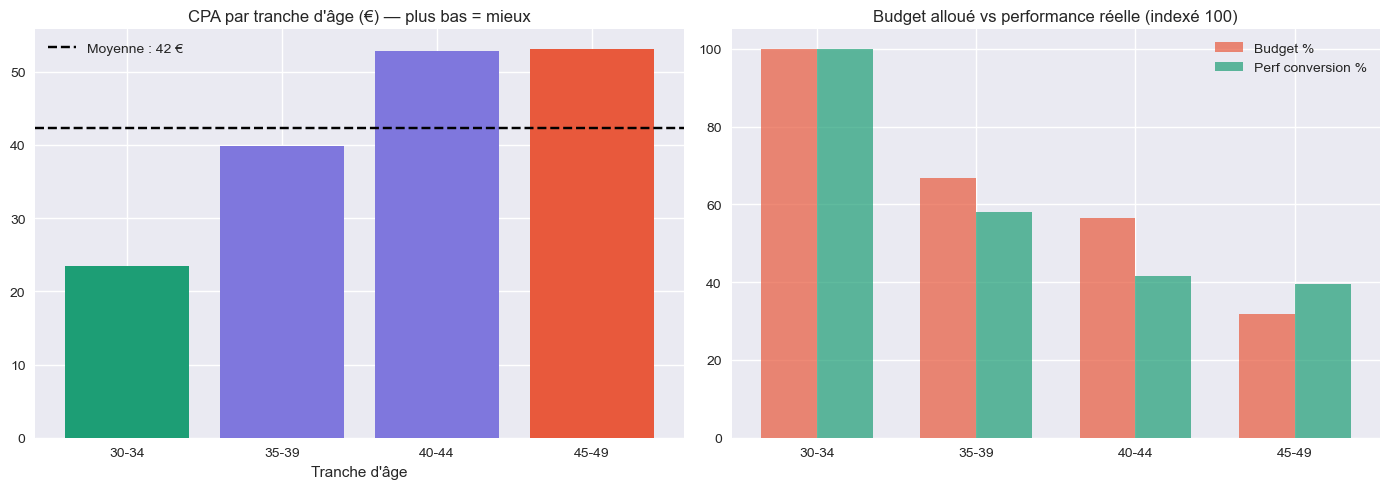


Analyse complète terminée !


In [12]:
print("=== INSIGHTS CIBLAGE ===")
print("""
TRANCHE D'ÂGE — Résultat sans appel
- 30-34 ans : taux de conversion 7.40% — meilleur segment de loin
- 45-49 ans : taux de conversion 2.92% — 2.5x moins efficace
→ RECOMMANDATION : Concentrer 70% du budget sur les 30-34 ans
→ Tester un ciblage 30-34 exclusif sur la campagne 916

GENRE — Surprise importante
- Femmes : CPA 23.56 € — 34% moins cher que les hommes
- Hommes : reçoivent 87.5% du budget mais convertissent moins bien
→ RECOMMANDATION : Rééquilibrer vers les femmes 30-34 ans
→ C'est probablement le profil le plus rentable de tout le dataset
""")

# Confirmation : femmes 30-34 ans = profil idéal
profil_ideal = campagnes_reelles[
    (campagnes_reelles['age'] == '30-34') & 
    (campagnes_reelles['gender'] == 'F')
]

print("=== PROFIL IDÉAL : FEMMES 30-34 ANS ===")
print(f"Budget dépensé : {profil_ideal['spent'].sum():.0f} €")
print(f"Conversions : {profil_ideal['approved_conversion'].sum():.0f}")
print(f"CPA : {(profil_ideal['spent'].sum() / profil_ideal['approved_conversion'].sum()):.2f} €")
print(f"Taux de conversion : {(profil_ideal['approved_conversion'].sum() / profil_ideal['clicks'].sum() * 100):.2f} %")

# Graphique récapitulatif final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CPA par âge
age_sorted = age.sort_values('CPA')
colors = ['#1D9E75' if x == '30-34' else '#E8593C' if x == '45-49' else '#7F77DD' for x in age_sorted.index]
axes[0].bar(age_sorted.index, age_sorted['CPA'], color=colors)
axes[0].set_title('CPA par tranche d\'âge (€) — plus bas = mieux')
axes[0].set_xlabel('Tranche d\'âge')
axes[0].axhline(y=age['CPA'].mean(), color='black', linestyle='--', label=f'Moyenne : {age["CPA"].mean():.0f} €')
axes[0].legend()

# Budget vs conversions par âge
x = range(len(age))
width = 0.35
axes[1].bar([i - width/2 for i in x], age['budget'] / age['budget'].max() * 100, width, label='Budget %', color='#E8593C', alpha=0.7)
axes[1].bar([i + width/2 for i in x], age['taux_conversion'] / age['taux_conversion'].max() * 100, width, label='Perf conversion %', color='#1D9E75', alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(age.index)
axes[1].set_title('Budget alloué vs performance réelle (indexé 100)')
axes[1].legend()

plt.tight_layout()
plt.savefig('analyse_finale.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nAnalyse complète terminée !")